# IT Helpdesk Automation Agent
### A RAG + LangGraph agent that answers, escalates, or takes action

**What this project demonstrates:**
- Retrieval-Augmented Generation (RAG) over an IT helpdesk knowledge base
- A LangGraph agent that **routes** each query to one of three paths:
  1. **Answer** directly from the knowledge base (info request)
  2. **Take action** via a tool call (e.g. reset password request, access request) against a mock ticketing system
  3. **Escalate** to a human when confidence is low or the request is sensitive
- An **LLM-as-judge** evaluator that scores whether the agent chose the *right* path for each query
- A simple **monitoring dashboard** (as a pandas summary) showing escalation rate, tool-call success rate, and action-correctness score

This is the automation layer that turns a "RAG chatbot" into a system that can safely act on a user's behalf, with guardrails.

**Author:** Sanusi Isiaka Olatunji · [GitHub](https://github.com/sanusi009) · [LinkedIn](https://www.linkedin.com/in/sanusi-olatunji-43990198)


## 1. Setup
Install dependencies and set your Gemini API key (get one free at https://aistudio.google.com/apikey).

In [1]:
!pip install -q langgraph langchain langchain-community google-genai faiss-cpu sentence-transformers pandas


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 74.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 74.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 54.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 5.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.


In [2]:
import os
from getpass import getpass

# Paste your Gemini API key when prompted (input is hidden)
if not os.environ.get("GEMINI_API_KEY"):
    os.environ["GEMINI_API_KEY"] = getpass("Enter your Gemini API key: ")


Enter your Gemini API key: ··········


## 2. Mock IT Helpdesk Knowledge Base
A small set of internal-style IT articles. In a real deployment this would be your company's actual KB / ServiceNow articles.

In [3]:
KB_ARTICLES = [
    {
        "id": "kb001",
        "title": "How to reset your password",
        "content": "To reset your password, go to the self-service portal at portal.company.com/reset. "
                    "Enter your employee ID and follow the email verification link. Passwords must be "
                    "at least 12 characters and rotated every 90 days. If you are locked out after 3 failed "
                    "attempts, you must contact IT to unlock your account manually."
    },
    {
        "id": "kb002",
        "title": "Requesting VPN access",
        "content": "VPN access requires manager approval. Submit a request through the Access Request "
                    "Portal, select 'VPN - Remote Access', and your manager will receive an approval "
                    "notification. Provisioning typically takes 1 business day after approval."
    },
    {
        "id": "kb003",
        "title": "Setting up email on a mobile device",
        "content": "Install the Outlook mobile app, sign in with your corporate email and password, and "
                    "approve the MFA push notification on your authenticator app. Corporate email cannot "
                    "be configured in the native iOS/Android mail apps due to security policy."
    },
    {
        "id": "kb004",
        "title": "Printer not responding troubleshooting",
        "content": "First check the printer is powered on and connected to the network. Restart the print "
                    "spooler service from Settings > Printers > Troubleshoot. If the issue persists after a "
                    "restart, the printer driver may need reinstalling."
    },
    {
        "id": "kb005",
        "title": "Software installation policy",
        "content": "Employees cannot install software outside the approved Software Center catalog. "
                    "Requests for new software must go through IT Procurement with a business justification "
                    "and manager sign-off, and are reviewed for security compliance before approval."
    },
]
print(f"Loaded {len(KB_ARTICLES)} KB articles")


Loaded 5 KB articles


## 3. Build the retrieval index
Using `sentence-transformers/all-MiniLM-L6-v2` (local, free, no API cost) for embeddings and FAISS for similarity search.

In [4]:
from sentence_transformers import SentenceTransformer
import faiss
import numpy as np

embedder = SentenceTransformer("all-MiniLM-L6-v2")

texts = [f"{a['title']}. {a['content']}" for a in KB_ARTICLES]
embeddings = embedder.encode(texts, normalize_embeddings=True)

dimension = embeddings.shape[1]
index = faiss.IndexFlatIP(dimension)  # cosine similarity via inner product on normalized vectors
index.add(np.array(embeddings, dtype="float32"))

def retrieve(query: str, k: int = 2):
    q_emb = embedder.encode([query], normalize_embeddings=True)
    scores, idxs = index.search(np.array(q_emb, dtype="float32"), k)
    results = []
    for score, idx in zip(scores[0], idxs[0]):
        article = KB_ARTICLES[idx]
        results.append({"article": article, "score": float(score)})
    return results

# quick sanity check
for r in retrieve("my printer is broken"):
    print(round(r["score"], 3), r["article"]["title"])


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

0.561 Printer not responding troubleshooting
0.176 How to reset your password


## 4. Mock action tools
These simulate a real ticketing system (e.g. ServiceNow, Jira Service Desk). In production these
would be real API calls — here they write to an in-memory store so the notebook is fully self-contained
and safe to run without any external system.

In [5]:
import uuid
import datetime

TICKET_DB = {}

def create_ticket(summary: str, category: str, requester: str = "demo_user") -> dict:
    """Create a helpdesk ticket. Use for action requests like password resets or access requests."""
    ticket_id = f"TCK-{uuid.uuid4().hex[:6].upper()}"
    ticket = {
        "ticket_id": ticket_id,
        "summary": summary,
        "category": category,
        "requester": requester,
        "status": "open",
        "created_at": datetime.datetime.utcnow().isoformat()
    }
    TICKET_DB[ticket_id] = ticket
    return ticket

def check_ticket_status(ticket_id: str) -> dict:
    """Check the status of an existing ticket."""
    return TICKET_DB.get(ticket_id, {"error": "ticket not found"})

def escalate_to_human(reason: str, query: str) -> dict:
    """Escalate a query to a human agent. Use when confidence is low or the request is sensitive."""
    ticket = create_ticket(summary=f"ESCALATION: {query}", category="human_escalation")
    ticket["escalation_reason"] = reason
    return ticket

TOOLS_SPEC = {
    "create_ticket": create_ticket,
    "check_ticket_status": check_ticket_status,
    "escalate_to_human": escalate_to_human,
}
print("Mock tools ready:", list(TOOLS_SPEC.keys()))


Mock tools ready: ['create_ticket', 'check_ticket_status', 'escalate_to_human']


## 5. LLM call helper (Gemini)

In [6]:
from google import genai
from google.genai import types
from google.genai.errors import ClientError
import time

client = genai.Client(api_key=os.environ["GEMINI_API_KEY"])
GEMINI_MODEL = "models/gemini-2.5-flash"

# --- Rate limiting -----------------------------------------------------
# The free tier caps requests at 5/minute (1 call every 12s). This notebook
# makes 2-3 calls per query (router + answer/action + judge), so pacing must
# happen BEFORE every call, not just after a 429 is hit, or bursts of calls
# within a single query will still trip the limit.
MIN_SECONDS_BETWEEN_CALLS = 13
_last_call_time = [0.0]

def _throttle():
    elapsed = time.time() - _last_call_time[0]
    if elapsed < MIN_SECONDS_BETWEEN_CALLS:
        time.sleep(MIN_SECONDS_BETWEEN_CALLS - elapsed)
    _last_call_time[0] = time.time()

def call_llm(prompt: str, system_instruction: str = "", max_retries: int = 5) -> str:
    """Call Gemini with built-in pacing plus retry/backoff as a safety net.
    Pacing (via _throttle) prevents most 429s from happening at all; the retry
    loop below is a fallback in case the free-tier quota still gets hit."""
    for attempt in range(max_retries):
        _throttle()
        try:
            response = client.models.generate_content(
                model=GEMINI_MODEL,
                contents=prompt,
                config=types.GenerateContentConfig(system_instruction=system_instruction) if system_instruction else None,
            )
            return response.text.strip()
        except ClientError as e:
            if getattr(e, "code", None) == 429 or "RESOURCE_EXHAUSTED" in str(e):
                wait = 20 * (attempt + 1)  # escalating backoff if still rate-limited despite pacing
                print(f"Rate limited, waiting {wait}s before retry ({attempt + 1}/{max_retries})...")
                time.sleep(wait)
            else:
                raise
    raise RuntimeError("Exceeded max retries due to rate limiting. Consider adding a billing account "
                        "to your Gemini API key for higher quota, increasing MIN_SECONDS_BETWEEN_CALLS, "
                        "or waiting a minute before re-running this cell.")

print(call_llm("Say 'ready' if you can read this."))


Ready.


## 6. The LangGraph agent

**State machine:**
```
classify_query --> (info)    --> retrieve_and_answer --> END
                --> (action)  --> take_action          --> END
                --> (escalate)--> escalate             --> END
```

The **classify_query** node is the router: it decides whether the query is an information
request, an action request, or should be escalated (low confidence / sensitive / out of scope).
This routing decision is the core "automation" logic — it's what separates this from a plain
RAG chatbot.

In [7]:
from typing import TypedDict, Literal, Optional
from langgraph.graph import StateGraph, END

class AgentState(TypedDict):
    query: str
    route: Optional[str]
    retrieved: Optional[list]
    answer: Optional[str]
    tool_result: Optional[dict]

ROUTER_PROMPT = """You are a router for an IT helpdesk agent. Classify the user's query into exactly
one category. Respond with ONLY one word, no punctuation:

- INFO: the user is asking how to do something and a knowledge-base answer is sufficient
- ACTION: the user is explicitly requesting an action be taken for them (e.g. "reset my password",
  "request VPN access", "create a ticket for X")
- ESCALATE: the request is ambiguous, sensitive (e.g. account security incident, HR-adjacent,
  legal), or clearly outside IT helpdesk scope

Query: {query}
Category:"""

def classify_query(state: AgentState) -> AgentState:
    result = call_llm(ROUTER_PROMPT.format(query=state["query"]))
    route = result.strip().upper()
    if route not in ("INFO", "ACTION", "ESCALATE"):
        route = "ESCALATE"  # fail safe: default to human escalation on ambiguous router output
    state["route"] = route
    return state

def retrieve_and_answer(state: AgentState) -> AgentState:
    hits = retrieve(state["query"], k=2)
    state["retrieved"] = hits
    # Confidence guardrail: if the best match score is too low, escalate instead of guessing
    if not hits or hits[0]["score"] < 0.35:
        state["route"] = "ESCALATE"
        return state
    context = "\n\n".join(f"{h['article']['title']}: {h['article']['content']}" for h in hits)
    answer_prompt = f"Using ONLY this context, answer the user's question concisely.\n\nContext:\n{context}\n\nQuestion: {state['query']}\nAnswer:"
    state["answer"] = call_llm(answer_prompt)
    return state

ACTION_PROMPT = """A user made this IT helpdesk request: "{query}"

Decide which single tool to call and extract the arguments. Respond in this exact format:
TOOL: <create_ticket|escalate_to_human>
SUMMARY: <short summary>
CATEGORY: <category>"""

def take_action(state: AgentState) -> AgentState:
    decision = call_llm(ACTION_PROMPT.format(query=state["query"]))
    lines = {l.split(":", 1)[0].strip(): l.split(":", 1)[1].strip() for l in decision.splitlines() if ":" in l}
    tool_name = lines.get("TOOL", "create_ticket")
    summary = lines.get("SUMMARY", state["query"])
    category = lines.get("CATEGORY", "general")
    if tool_name not in TOOLS_SPEC:
        tool_name = "create_ticket"
    ticket = create_ticket(summary=summary, category=category)
    state["tool_result"] = {"tool_called": tool_name, "ticket": ticket}
    return state

def escalate(state: AgentState) -> AgentState:
    ticket = escalate_to_human(reason="Router flagged for human review", query=state["query"])
    state["tool_result"] = {"tool_called": "escalate_to_human", "ticket": ticket}
    return state

def route_decision(state: AgentState) -> str:
    return state["route"].lower()

graph = StateGraph(AgentState)
graph.add_node("classify_query", classify_query)
graph.add_node("retrieve_and_answer", retrieve_and_answer)
graph.add_node("take_action", take_action)
graph.add_node("escalate", escalate)

graph.set_entry_point("classify_query")
graph.add_conditional_edges("classify_query", route_decision, {
    "info": "retrieve_and_answer",
    "action": "take_action",
    "escalate": "escalate",
})
# retrieve_and_answer can itself downgrade to escalate (low confidence guardrail)
graph.add_conditional_edges("retrieve_and_answer", lambda s: "escalate" if s["route"] == "ESCALATE" else "end", {
    "escalate": "escalate",
    "end": END,
})
graph.add_edge("take_action", END)
graph.add_edge("escalate", END)

agent = graph.compile()
print("Agent graph compiled.")


Agent graph compiled.


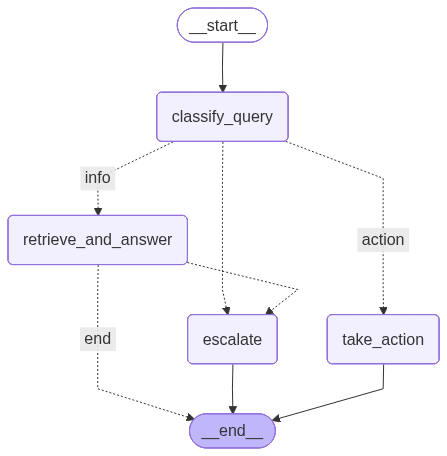

In [8]:
agent

## 7. Run the agent on sample queries

In [9]:
demo_queries = [
    "How do I set up my email on my phone?",
    "Please reset my password, I forgot it",
    "My manager approved my VPN access last week but I still can'\''t connect, and I think someone else logged into my account",
    "My printer keeps saying offline",
    "I need software installed that isn'\''t in the approved catalog for a client demo tomorrow",
]

# NOTE: each query makes 1-2 Gemini calls (router + answer/action). On the free tier
# (5 requests/minute) a short pause between queries avoids 429 rate-limit errors.
import time

results = []
for q in demo_queries:
    state = {"query": q, "route": None, "retrieved": None, "answer": None, "tool_result": None}
    final_state = agent.invoke(state)
    results.append(final_state)
    print(f"Query: {q}")
    print(f"  Route: {final_state['route']}")
    if final_state.get("answer"):
        print(f"  Answer: {final_state['answer']}")
    if final_state.get("tool_result"):
        print(f"  Tool result: {final_state['tool_result']}")
    print()


Query: How do I set up my email on my phone?
  Route: INFO
  Answer: Install the Outlook mobile app, sign in with your corporate email and password, and approve the MFA push notification on your authenticator app. Corporate email cannot be configured in native iOS/Android mail apps.



/tmp/ipykernel_870/350099068.py:15: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "created_at": datetime.datetime.utcnow().isoformat()


Query: Please reset my password, I forgot it
  Route: ACTION
  Tool result: {'tool_called': 'create_ticket', 'ticket': {'ticket_id': 'TCK-1E2924', 'summary': 'User forgot their password and needs it reset. Identity verification will be required before proceeding.', 'category': 'Password Reset', 'requester': 'demo_user', 'status': 'open', 'created_at': '2026-07-11T12:51:17.473225'}}

Query: My manager approved my VPN access last week but I still can'''t connect, and I think someone else logged into my account
  Route: ESCALATE
  Tool result: {'tool_called': 'escalate_to_human', 'ticket': {'ticket_id': 'TCK-7F8A6A', 'summary': "ESCALATION: My manager approved my VPN access last week but I still can'''t connect, and I think someone else logged into my account", 'category': 'human_escalation', 'requester': 'demo_user', 'status': 'open', 'created_at': '2026-07-11T12:51:29.427449', 'escalation_reason': 'Router flagged for human review'}}

Query: My printer keeps saying offline
  Route: INFO


## 8. LLM-as-judge: was the routing decision correct?

This is the guardrail/evaluation layer. For each query we ask a separate LLM call to judge whether
the agent's chosen route (INFO / ACTION / ESCALATE) was the appropriate one, given the query. This
is the same evaluation pattern used in the RAG pipeline project, applied here to *actions* instead
of just retrieved answers.

In [10]:
JUDGE_PROMPT = """You are auditing an IT helpdesk automation agent. Given the user query and the
route the agent chose, judge whether the route was appropriate.

Query: {query}
Agent's chosen route: {route}

Valid routes and when they are correct:
- INFO: correct if the query is a how-to question answerable from a knowledge base
- ACTION: correct if the query is an explicit request to do something (reset password, request access)
- ESCALATE: correct if the query is ambiguous, security-sensitive, or mentions a possible incident

Respond in this exact format:
VERDICT: <CORRECT|INCORRECT>
REASON: <one sentence>"""

judged = []
for r in results:
    verdict_text = call_llm(JUDGE_PROMPT.format(query=r["query"], route=r["route"]))
    verdict = "CORRECT" if "CORRECT" in verdict_text.upper() and "INCORRECT" not in verdict_text.upper() else "INCORRECT"
    judged.append({"query": r["query"], "route": r["route"], "verdict": verdict, "judge_notes": verdict_text})

for j in judged:
    print(f"[{j['verdict']}] {j['query'][:60]}... -> {j['route']}")


[CORRECT] How do I set up my email on my phone?... -> INFO
[CORRECT] Please reset my password, I forgot it... -> ACTION
[CORRECT] My manager approved my VPN access last week but I still can'... -> ESCALATE
[CORRECT] My printer keeps saying offline... -> INFO
[CORRECT] I need software installed that isn'''t in the approved catal... -> ESCALATE


## 9. Monitoring summary
A lightweight stand-in for a production observability dashboard (e.g. the Gradio dashboard from the RAG pipeline project, extended with an 'Actions' tab).

In [11]:
import pandas as pd

df = pd.DataFrame(judged)

summary = {
    "total_queries": len(df),
    "escalation_rate": round((df["route"] == "ESCALATE").mean(), 2),
    "action_rate": round((df["route"] == "ACTION").mean(), 2),
    "info_rate": round((df["route"] == "INFO").mean(), 2),
    "routing_accuracy_per_judge": round((df["verdict"] == "CORRECT").mean(), 2),
    "tickets_created": len(TICKET_DB),
}

print("=== Monitoring Summary ===")
for k, v in summary.items():
    print(f"{k}: {v}")

df


=== Monitoring Summary ===
total_queries: 5
escalation_rate: 0.4
action_rate: 0.2
info_rate: 0.4
routing_accuracy_per_judge: 1.0
tickets_created: 3


,query,route,verdict,judge_notes
0,How do I set up my email on my phone?,INFO,CORRECT,VERDICT: CORRECT\nREASON: The query is a how-t...
1,"Please reset my password, I forgot it",ACTION,CORRECT,VERDICT: CORRECT\nREASON: The query is an expl...
2,My manager approved my VPN access last week bu...,ESCALATE,CORRECT,VERDICT: CORRECT\nREASON: The query mentions a...
3,My printer keeps saying offline,INFO,CORRECT,VERDICT: CORRECT\nREASON: Although the query d...
4,I need software installed that isn'''t in the ...,ESCALATE,CORRECT,VERDICT: CORRECT\nREASON: The request to insta...


## 10. Gradio web UI

A simple two-tab interface so you can demo this interactively instead of reading printed logs:

- **Agent Chat** — type a query, see the router's decision, the answer or tool result, live
- **Monitoring Dashboard** — running stats across every query submitted in this session (escalation rate, action rate, judge-scored routing accuracy), plus the full history table

This reuses the exact same `agent`, `call_llm`, and `JUDGE_PROMPT` defined above — the UI is just a thin layer on top of the pipeline you already built and tested.

In [12]:
!pip install -q gradio


In [13]:
import gradio as gr
import pandas as pd
import time

# Running history for this session, used to populate the monitoring dashboard
SESSION_HISTORY = []

def run_agent_and_judge(query: str):
    """Runs one query through the agent, then through the LLM judge, and logs it to SESSION_HISTORY."""
    if not query or not query.strip():
        return "Please enter a query.", "", pd.DataFrame()

    state = {"query": query, "route": None, "retrieved": None, "answer": None, "tool_result": None}
    final_state = agent.invoke(state)

    # Judge the routing decision (same prompt used in the batch eval above)
    verdict_text = call_llm(JUDGE_PROMPT.format(query=query, route=final_state["route"]))
    verdict = "CORRECT" if "CORRECT" in verdict_text.upper() and "INCORRECT" not in verdict_text.upper() else "INCORRECT"

    record = {
        "query": query,
        "route": final_state["route"],
        "answer": final_state.get("answer") or "",
        "tool_result": str(final_state.get("tool_result") or ""),
        "judge_verdict": verdict,
    }
    SESSION_HISTORY.append(record)

    # Build the chat-facing response
    route = final_state["route"]
    if route == "INFO":
        response = f"**Route: INFO**\n\n{final_state['answer']}"
    elif route == "ACTION":
        tr = final_state["tool_result"]
        response = (f"**Route: ACTION**\n\nTool called: `{tr['tool_called']}`\n\n"
                    f"Ticket created: `{tr['ticket']['ticket_id']}` — {tr['ticket']['summary']} "
                    f"(category: {tr['ticket']['category']})")
    else:  # ESCALATE
        tr = final_state["tool_result"]
        response = (f"**Route: ESCALATE**\n\nEscalated to a human. "
                    f"Ticket: `{tr['ticket']['ticket_id']}`\n\n"
                    f"Reason: {tr['ticket'].get('escalation_reason', 'n/a')}")

    judge_note = f"*Judge verdict: **{verdict}*** — {verdict_text.split(chr(10))[-1] if chr(10) in verdict_text else verdict_text}"

    return response, judge_note, get_monitoring_df()


def get_monitoring_df() -> pd.DataFrame:
    if not SESSION_HISTORY:
        return pd.DataFrame(columns=["query", "route", "judge_verdict"])
    return pd.DataFrame(SESSION_HISTORY)[["query", "route", "judge_verdict"]]


def get_summary_stats():
    if not SESSION_HISTORY:
        return "No queries submitted yet this session."
    df = pd.DataFrame(SESSION_HISTORY)
    total = len(df)
    escalation_rate = round((df["route"] == "ESCALATE").mean(), 2)
    action_rate = round((df["route"] == "ACTION").mean(), 2)
    info_rate = round((df["route"] == "INFO").mean(), 2)
    accuracy = round((df["judge_verdict"] == "CORRECT").mean(), 2)
    return (f"**Total queries:** {total}  \n"
            f"**Escalation rate:** {escalation_rate}  \n"
            f"**Action rate:** {action_rate}  \n"
            f"**Info rate:** {info_rate}  \n"
            f"**Judge-scored routing accuracy:** {accuracy}  \n"
            f"**Tickets created (total, incl. escalations):** {len(TICKET_DB)}")


def refresh_dashboard():
    return get_summary_stats(), get_monitoring_df()


with gr.Blocks(title="IT Helpdesk Automation Agent") as demo:
    gr.Markdown("# IT Helpdesk Automation Agent\nRAG + LangGraph agent that answers, acts, or escalates.")

    with gr.Tabs():
        with gr.Tab("Agent Chat"):
            with gr.Row():
                query_box = gr.Textbox(label="Ask the helpdesk agent", placeholder="e.g. How do I reset my password?", lines=2)
            submit_btn = gr.Button("Submit", variant="primary")
            response_box = gr.Markdown(label="Agent response")
            judge_box = gr.Markdown(label="Judge verdict")
            history_table_chat = gr.Dataframe(label="Session history", interactive=False)

            submit_btn.click(
                fn=run_agent_and_judge,
                inputs=query_box,
                outputs=[response_box, judge_box, history_table_chat],
            )
            query_box.submit(
                fn=run_agent_and_judge,
                inputs=query_box,
                outputs=[response_box, judge_box, history_table_chat],
            )

        with gr.Tab("Monitoring Dashboard"):
            refresh_btn = gr.Button("Refresh")
            stats_box = gr.Markdown()
            history_table_monitor = gr.Dataframe(label="Full session history", interactive=False)

            refresh_btn.click(fn=refresh_dashboard, outputs=[stats_box, history_table_monitor])
            demo.load(fn=refresh_dashboard, outputs=[stats_box, history_table_monitor])

demo.launch(share=True, debug=False)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://fd631d124ecaa50ff4.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## 11. Next steps for a real deployment

- Replace the mock `TICKET_DB` with real API calls (ServiceNow, Jira Service Desk, Zendesk)
- Add a **human-in-the-loop confirmation step** before any `take_action` call executes (LangGraph
  supports interrupting a run and resuming after approval)
- Track drift over time by re-running the judge weekly and watching `routing_accuracy_per_judge`
- Swap `all-MiniLM-L6-v2` for `gemini-embedding-001` for higher-quality retrieval at larger KB scale
- Add persistent checkpointing (LangGraph's `checkpointer`) so conversations survive restarts

---
*This project is part of a portfolio exploring agentic automation on top of production-style RAG
pipelines. Feedback and forks welcome.*
